In [90]:
import matplotlib.pyplot as plt
import numpy as np
from math import *
from pylab import *

### Problem 1 - Comet orbits

Alternative **a)** Turn this two equations in four of first order:

$$ f(x) = \frac{dx}{dt} = v_{x} \hspace{1cm} \rightarrow \hspace{1cm} f(v_{x}) = \frac{dv_{x}}{dt} = -GM \frac{x}{r^{3}} $$

where $\hspace{1cm} r = \sqrt{x^{2} + y^{2}} \hspace{1cm}$ using the same analogy to y:

$$ f(y) = \frac{dy}{dt} = v_{y} \hspace{1cm} \rightarrow \hspace{1cm} f(v_{y}) = \frac{dv_{y}}{dt} = -GM \frac{y}{r^{3}} $$

Alternative **b)** Solve the equations and plot the trajetory of the comet:

In [91]:
def func1(r_array, t):
  G = 6.67e-11
  M = 1.98898e30

  x, y = r_array[0], r_array[1]
  vx, vy = r_array[2], r_array[3]

  r = sqrt(x**2 + y**2)

  fx = vx
  fy = vy

  fvx = -(G*M/r**3)*x
  fvy = -(G*M/r**3)*y

  return array([fx, fy, fvx, fvy], float)

def rouge_kutta_10_1(tpoints, r1, func_name, questC):

  x_points, vx_points = [], []
  y_points, vy_points = [], []

  for t in tpoints:
    x_points.append(r1[0])
    y_points.append(r1[1])

    vx_points.append(r1[2])
    vy_points.append(r1[3])

    k1 = h*func_name(r1, t)
    k2 = h*func_name(r1+0.5*k1, t+0.5*h)
    k3 = h*func_name(r1+0.5*k2, t+0.5*h)
    k4 = h*func_name(r1+k3, t+h)

    r1 += (k1+2*k2+2*k3+k4)/6

    if questC == True:
        h += 1000
    else:
        h += 0

  return x_points, y_points, vx_points, vy_points

In [92]:
a = 0
b = 3*1e9
N = 1e5
h = (b-a)/N
tpoints = arange(a, b, h)

r1 = array([4e12, 0, 0, 500], float)

x, y, vx, vy = rouge_kutta_10_1(tpoints, r1, func1, False)

xlabel('x axis')
ylabel('y label')
plot(x, y)
show()

UnboundLocalError: cannot access local variable 'h' where it is not associated with a value

Alternative **c)**

In [ ]:
a = 0
b = 3*1e9
N = 1e5
h = (b-a)/N
tpoints = arange(a, b, h)

r1 = array([4e12, 0, 0, 500], float)

x, y, vx, vy = rouge_kutta_10_1(tpoints, r1, func1, True)

xlabel('x axis')
ylabel('y label')
plot(x, y)
show()

### Problem 2 - EDO solution

Solve the differential equation below using the **leapfrog** method:

$$ \frac{d^{2}x}{dt^{2}} = \left(\frac{dx}{dt}\right)^{2} - x - 5$$

$$ \frac{dx}{dt} = v \hspace{1cm} \text{and} \hspace{1cm} \frac{dv}{dt} = v^{2} - x - 5 $$

In [85]:
def func2(r, t):

  x, v = r[0], r[1]

  fx = v
  fvx = v**2 - x - 5
  return np.array([fx, fvx], float)

def leapfrog_10_2(tpoints, r1, func_name):
    x_points = []
    vx_points = []

    v_half = r1[0] + 0.5 * h * func_name(r1, tpoints[0])[0]

    for t in tpoints:
        x_points.append(r1[0])
        vx_points.append(r1[1])

        r1[0] += h * v_half
        accel = func_name(r1, t + h)[1]
        v_half += h * accel

    return x_points, vx_points

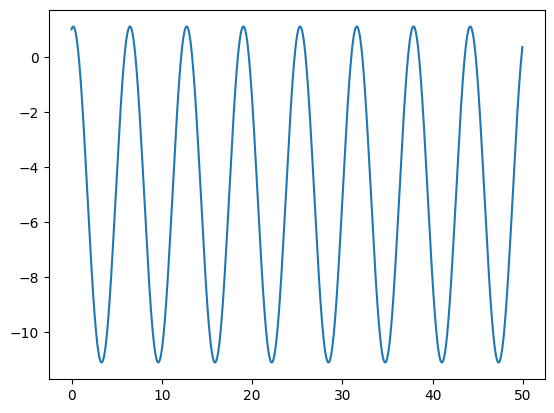

In [34]:
a = 0
b = 50

N = 1000
h = (b-a)/N

tpoints = arange(a, b, h)

r2 = array([1, 0], float)

x, vx = leapfrog_10_2(tpoints, r2, func2)

plot(tpoints, x)
show()

### Problem 3 - Earth orbit

In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [55]:
G = 6.6738e-11
M = 1.9891e30
m = 5.9722e24

h = 3600
anos = 5
tempo_total = anos * 365 * 24 * 3600 
passos = int(tempo_total / h)

x0, y0 = 1.4710e11, 0.0
vx0, vy0 = 0.0, 3.0287e4

t_array = np.zeros(passos)
x_array = np.zeros(passos)
y_array = np.zeros(passos)
vx_array = np.zeros(passos)
vy_array = np.zeros(passos)

x_array[0], y_array[0] = x0, y0
vx_array[0], vy_array[0] = vx0, vy0

In [56]:
def aceleracao(x, y):
    r = np.sqrt(x**2 + y**2)
    ax = -G * M * x / r**3
    ay = -G * M * y / r**3
    return ax, ay

In [87]:
# Equação 8.77
ax0, ay0 = aceleracao(x0, y0)
v_meio_x = vx0 + 0.5 * h * ax0
v_meio_y = vy0 + 0.5 * h * ay0

# Equações 8.78a até 8.78d
for i in range(passos-1):
    t_array[i+1] = (i+1) * h
    
    # (8.78a) Atualiza a posição
    x_array[i+1] = x_array[i] + h * v_meio_x
    y_array[i+1] = y_array[i] + h * v_meio_y
    
    # (8.78b)
    ax_novo, ay_novo = aceleracao(x_array[i+1], y_array[i+1])
    kx = h * ax_novo
    ky = h * ay_novo
    
    # (8.78c)
    vx_array[i+1] = v_meio_x + 0.5 * kx
    vy_array[i+1] = v_meio_y + 0.5 * ky
    
    # (8.78d)
    v_meio_x = v_meio_x + kx
    v_meio_y = v_meio_y + ky

r_mags = np.sqrt(x_array**2 + y_array**2)
v_quadrados = vx_array**2 + vy_array**2

E_potencial = -G * M * m / r_mags
E_cinetica = 0.5 * m * v_quadrados
E_total = E_potencial + E_cinetica

t_dias = t_array / (24 * 3600)

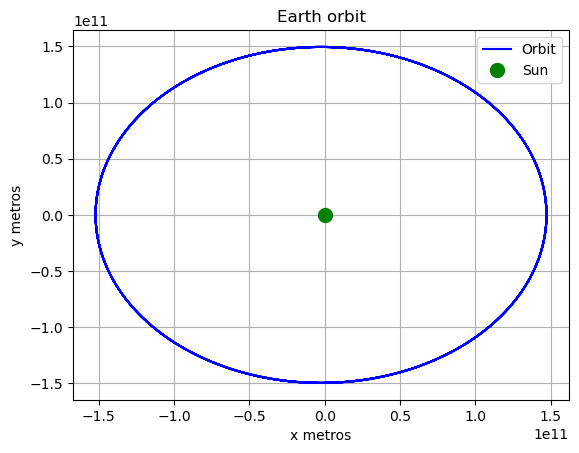

In [59]:
plt.plot(x_array, y_array, label='Orbit', color='blue')
plt.plot(0, 0, 'go', label='Sun', markersize=10)

plt.title('Earth orbit')
plt.xlabel('x metros')
plt.ylabel('y metros')

plt.grid(True)
plt.legend()
plt.show()

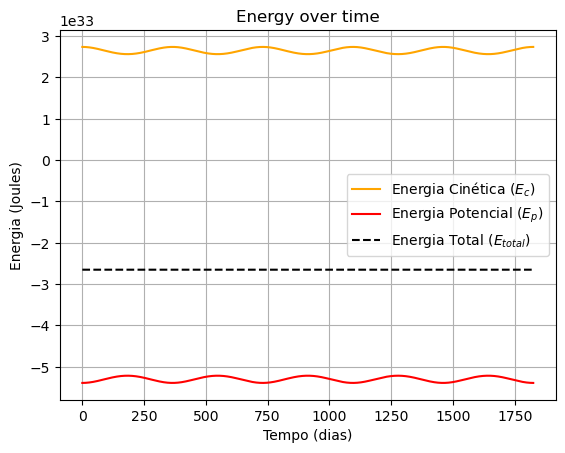

In [60]:
plt.plot(t_dias, E_cinetica, label='Energia Cinética ($E_c$)', color='orange')
plt.plot(t_dias, E_potencial, label='Energia Potencial ($E_p$)', color='red')
plt.plot(t_dias, E_total, label='Energia Total ($E_{total}$)', color='black', linestyle='--')

plt.title('Energy over time')
plt.xlabel('Tempo (dias)')
plt.ylabel('Energia (Joules)')

plt.grid(True)
plt.legend()
plt.show()

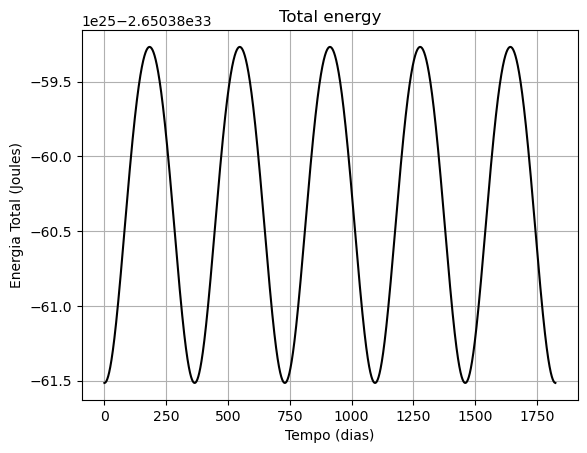

In [63]:
plt.plot(t_dias, E_total, color='black')

plt.title('Total energy')
plt.xlabel('Tempo (dias)')
plt.ylabel('Energia Total (Joules)')
plt.grid(True)

# plt.ylim(np.min(E_total)*1.0001, np.max(E_total)*0.9999) 

plt.show()

### Problem 4

In [64]:
m = 1.0
R = 0.08
rho = 1.22
C = 0.47
g = 9.81
v0 = 100.0
alvo = 200.0
precisao = 0.1

gamma = (np.pi * (R**2) * rho * C) / (2.0 * m)

h = 0.001

In [76]:
def simular_trajetoria(theta):
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    
    def aceleracao(vx_atual, vy_atual):
        v = np.sqrt(vx_atual**2 + vy_atual**2)
        ax = -gamma * vx_atual * v
        ay = -g - gamma * vy_atual * v
        return ax, ay

    ax, ay = aceleracao(vx, vy)
    v_meio_x = vx + 0.5 * h * ax
    v_meio_y = vy + 0.5 * h * ay
    
    while y >= 0.0:
        x += h * v_meio_x
        y += h * v_meio_y
        
        ax_nova, ay_nova = aceleracao(v_meio_x, v_meio_y)
        kx = h * ax_nova
        ky = h * ay_nova
        
        vx = v_meio_x + 0.5 * kx
        vy = v_meio_y + 0.5 * ky
        
        v_meio_x += kx
        v_meio_y += ky
        
    return x

In [77]:
theta_min = 0.0
theta_max = np.pi / 4.0

print(f"Ângulo (graus)   Alcance (m)  Erro (m)")
print("-" * 45)

while True:
    theta_teste = (theta_min + theta_max) / 2.0
    alcance_obtido = simular_trajetoria(theta_teste)
    erro = alcance_obtido - alvo
    
    print(f"{np.degrees(theta_teste):<18.4f}{alcance_obtido:<15.2f}{erro:<12.2f}")
    
    if abs(erro) <= precisao:
        angulo_final_graus = np.degrees(theta_teste)
        break

    if erro < 0:
        theta_min = theta_teste
    else:
        theta_max = theta_teste
print("-" * 45)

print(f"Ângulo necessário para o disparo: {angulo_final_graus:.3f}°")
print(f"Distância final calculada: {alcance_obtido:.2f} m")

Ângulo (graus)   Alcance (m)  Erro (m)
---------------------------------------------
22.5000           228.65         28.65       
11.2500           174.84         -25.16      
16.8750           208.15         8.15        
14.0625           193.48         -6.52       
15.4687           201.24         1.24        
14.7656           197.47         -2.53       
15.1172           199.37         -0.63       
15.2930           200.31         0.31        
15.2051           199.84         -0.16       
15.2490           200.08         0.08        
---------------------------------------------
Ângulo necessário para o disparo: 15.249°
Distância final calculada: 200.08 m
